In [11]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
sys.path.append(str(Path().resolve().parents[1]))

In [13]:
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from io import StringIO
import pandas as pd
import pickle
import igraph as ig
import torch

# Ensure the diffusion directory is on sys.path for local imports
DIFFUSION_DIR = str(Path().resolve())
if DIFFUSION_DIR not in sys.path:
    sys.path.insert(0, DIFFUSION_DIR)

from dataprep.util import create_pattern_dict, filter_dict
from dataprep.util import *
from dataprep.plotting_helpers import *
from dataprep.generation import *
from util import *
from plotting_helpers import *

from simclr import * 
from augmentation import *

In [14]:
# current_dir = os.path.dirname(os.getcwd())
# CSV_PATH = os.path.join(current_dir, "data", "IBM", "Hi-Small_Trans.csv")
path = r"C:\Users\lucsc\Thesis\grad\grad\data\IBM\HI-Small_Trans.csv"
df_full = preprocess_df(path)
# df_full = preprocess_df()

In [15]:
with_laund_networks = extract_laundering_networks_igraph(
    df_full,
    max_depth=4,
    max_networks=2000,
    collapse_threshold=10,
    max_nodes=300
) 

In [16]:
# laundering_networks = extract_laundering_networks_igraph(df)

# Grab their sizes to match

non_laundering_networks = extract_non_laundering_networks_igraph(
    df_full,
    max_depth=4,
    max_networks=len(with_laund_networks),
    collapse_threshold=10,
    max_nodes=300)

In [17]:
networks = with_laund_networks + non_laundering_networks # laundering + non-laundering

for net in networks:
    net["graph"] = build_igraph_from_transactions(net["transactions"])

In [18]:
# import torch
# import numpy as np
# import umap
# import matplotlib.pyplot as plt

# from torch_geometric.data import Batch

# def plot_simclr_latent_space_laundering_vs_clean(
#     networks,
#     df_full
# ):
#     """
#     Plot the SimCLR encoder latent space, colored by presence of laundering nodes.
#     """ 

#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#     checkpoint = torch.load("model_checkpoints/best_model.pt", map_location=device)

#     encoder = GraphEncoder(in_dim=7, hidden_dim=64, out_dim=128).to(device)
#     encoder.load_state_dict(checkpoint["encoder_state_dict"])
#     encoder.eval()

#     full_graph = prepare_networks(networks, df_full)

#     graphs = []
#     labels = []   # 1 = laundering present, 0 = none

#     for net in networks:
#         v = augment_network_view_fast(net, full_graph)
#         graphs.append(network_to_pyg_data_fast(v))

#         has_laundering = len(net["laundering_nodes"]) > 0
#         labels.append(int(has_laundering))

#     labels = np.array(labels)

#     data = Batch.from_data_list(graphs).to(device)

#     with torch.no_grad():
#         h = encoder(data)

#     H = h.cpu().numpy()

#     # Normalize (important for contrastive models)
#     H = H / np.linalg.norm(H, axis=1, keepdims=True)

#     reducer = umap.UMAP(
#         n_neighbors=15,
#         min_dist=0.1,
#         metric="cosine",
#         random_state=42
#     )

#     H_2d = reducer.fit_transform(H)

#     plt.figure(figsize=(8, 8))

#     scatter = plt.scatter(
#         H_2d[:, 0],
#         H_2d[:, 1],
#         c=labels,
#         cmap="coolwarm",   # blue = non-laundering, red = laundering
#         s=30,
#         alpha=0.85
#     )

#     plt.title("SimCLR Encoder Latent Space\nRed = Laundering Networks | Blue = Clean Networks")
#     plt.xticks([])
#     plt.yticks([])

#     cbar = plt.colorbar(scatter, ticks=[0, 1])
#     cbar.ax.set_yticklabels(["No laundering nodes", "Has laundering nodes"])

#     plt.tight_layout()
#     plt.show()

#     plt.savefig("simclr_latent_space_laundering_vs_clean.png", dpi=300)


c:\Users\lucsc\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved plot to C:\Users\lucsc\Thesis\grad\grad\igraph_version\simclr\simclr_latent_space_laundering_vs_clean.png


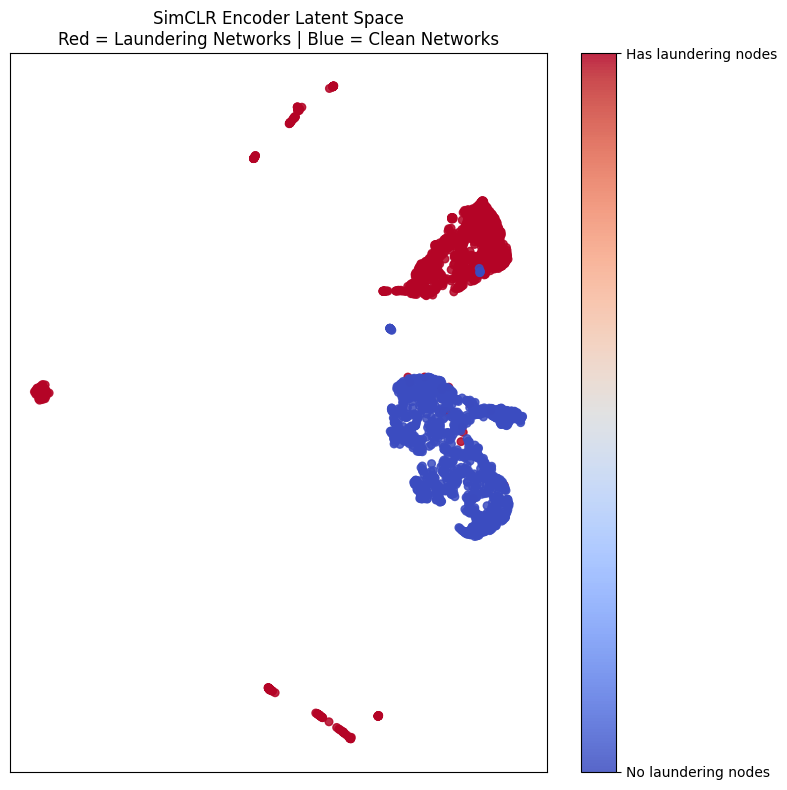

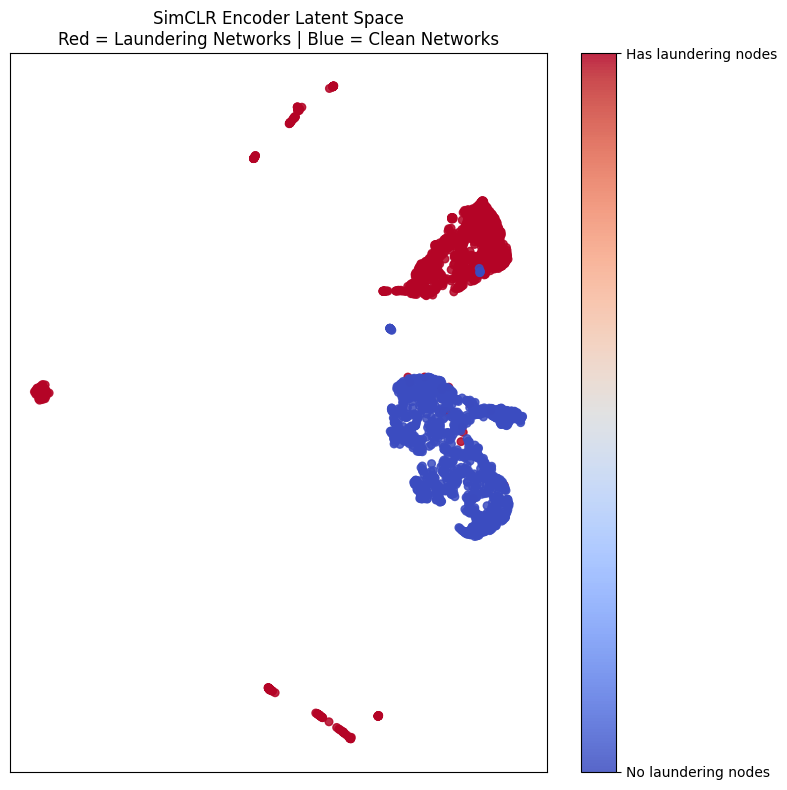

In [19]:
plot_simclr_latent_space_laundering_vs_clean(networks, df_full) 

In [ ]:

# ═══════════════════════════════════════════════════════════════════
# GUIDED GENERATION  —  SimCLR probe + novelty repulsion
# ═══════════════════════════════════════════════════════════════════

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, umap, matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from torch_geometric.data import Data, Batch

SIMCLR_DIR = Path(r"C:\Users\lucsc\Thesis\grad\grad\igraph_version\simclr")
DIFF_DIR   = Path(r"C:\Users\lucsc\Thesis\grad\grad\igraph_version\diffusion")
MAX_NODES  = 300
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 1. Load best SimCLR checkpoint ───────────────────────────────────────────
ckpt_dir = SIMCLR_DIR / "model_checkpoints"
candidates = list(ckpt_dir.glob("*.pt"))
best_ckpt_path, best_loss = None, float("inf")
for p in candidates:
    try:
        c = torch.load(p, map_location="cpu", weights_only=False)
        if isinstance(c, dict) and "loss" in c and c["loss"] < best_loss:
            best_loss, best_ckpt_path = c["loss"], p
    except Exception:
        pass
print(f"Best checkpoint: {best_ckpt_path.name}  (loss={best_loss:.4f})")

simclr_ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
encoder = GraphEncoder(in_dim=7, hidden_dim=64, out_dim=128).to(device)
encoder.load_state_dict(simclr_ckpt["encoder_state_dict"])
encoder.eval()

# ── 2. Load diffusion model ───────────────────────────────────────────────────
from diffusion.model     import DiffusionGNN
from diffusion.diff_util import create_diffusion, network_to_dense

diff_ckpt  = torch.load(DIFF_DIR / "model.pt", map_location=device, weights_only=False)
diff_model = DiffusionGNN(node_dim=7, hidden_dim=128, num_layers=4).to(device)
diff_model.load_state_dict(diff_ckpt["model"])
diff_model.eval()
diffusion  = create_diffusion(T=500)
x_mean     = diff_ckpt["x_mean"].to(device)
x_std      = diff_ckpt["x_std"].to(device)
print("Diffusion model loaded.")

# ── 3. Encode all training networks ──────────────────────────────────────────
all_graphs, all_labels = [], []
for net in networks:
    v = augment_network_view_fast(net)
    all_graphs.append(network_to_pyg_data_fast(v))
    all_labels.append(int(len(net["laundering_nodes"]) > 0))

with torch.no_grad():
    H_all = encoder(Batch.from_data_list(all_graphs).to(device)).cpu()
H_all_n = F.normalize(H_all, dim=1)          # [N, 128]  — kept on CPU
y_all   = torch.tensor(all_labels, dtype=torch.float32)

# ── 4. Train MLP probe ────────────────────────────────────────────────────────
probe = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)).to(device)
opt   = torch.optim.Adam(probe.parameters(), lr=5e-3)
for _ in range(500):
    logit = probe(H_all_n.to(device)).squeeze(-1)
    loss  = F.binary_cross_entropy_with_logits(logit, y_all.to(device))
    opt.zero_grad(); loss.backward(); opt.step()
with torch.no_grad():
    preds = (torch.sigmoid(probe(H_all_n.to(device)).squeeze(-1)) > 0.5).cpu()
print(f"MLP probe accuracy: {(preds == y_all.bool()).float().mean():.3f}")
for p in probe.parameters():
    p.requires_grad_(False)

# ── helper: 7-feature PyG Data, no inplace ops ───────────────────────────────
def _to_pyg(x0_nodes, adj_soft, n, device):
    x_bin  = x0_nodes[:, 0:1].clamp(0.0, 1.0)
    x_cont = x0_nodes[:, 1:] * x_std[1:] + x_mean[1:]
    deg    = adj_soft.sum(dim=-1, keepdim=True)
    deg_n  = deg / deg.detach().max().clamp(min=1.0)
    x_feat = torch.cat([x_bin, deg_n, x_cont[:, 1:]], dim=-1)   # [n, 7]
    ei = (adj_soft.detach() > 0.5).nonzero(as_tuple=False).T.contiguous()
    if ei.shape[1] == 0:
        ei = torch.zeros(2, 0, dtype=torch.long, device=device)
    return Data(x=x_feat, edge_index=ei,
                batch=torch.zeros(n, dtype=torch.long, device=device))

# ── 5. Guided generation with novelty repulsion ───────────────────────────────
def guided_generate(seed_network, target_label=1,
                    t_start=350,
                    guidance_scale=2.0,
                    novelty_weight=2.0,   # repulsion from top-K training neighbours
                    novelty_k=10,
                    guide_every=5,
                    guide_from=0.6,
                    H_train=None,         # [N, 128] normalised training embeddings
                    pbar=None):
    """
    Two-objective guidance at each step:
      1. Classification loss  — steer towards target_label (laundering / clean)
      2. Novelty repulsion    — push embedding away from the K nearest training
                                 networks (minimised mean top-K cosine similarity)

    Higher t_start → more noise added to seed → more structural freedom.
    """
    if "x_dense" in seed_network and "adj_dense" in seed_network:
        x   = seed_network["x_dense"].to(device)
        adj = seed_network["adj_dense"].to(device)
    else:
        x, adj = network_to_dense(seed_network)
        x, adj = x.to(device), adj.to(device)
    n = x.shape[0]

    x_pad   = torch.zeros(1, MAX_NODES, 7,        device=device)
    adj_pad = torch.zeros(1, MAX_NODES, MAX_NODES, device=device)
    mask    = torch.zeros(1, MAX_NODES,            device=device)
    x_pad[0, :n]       = x;  adj_pad[0, :n, :n] = adj;  mask[0, :n] = 1.0

    x_norm = x_pad.clone()
    x_norm[:, :, 1:] = (x_pad[:, :, 1:] - x_mean[1:]) / x_std[1:]
    x_norm  = x_norm  * mask.unsqueeze(-1)
    adj_pad = adj_pad * mask[:, :, None] * mask[:, None, :]

    t_tensor   = torch.tensor([t_start], device=device)
    x_t, adj_t = diffusion.q_sample(x_norm, t_tensor, node_mask=mask, adj_start=adj_pad)

    guide_threshold = int(guide_from * t_start)
    cached_grad     = None

    H_dev = H_train.to(device) if H_train is not None else None

    for step_i, t_curr in enumerate(range(t_start, -1, -1)):
        t_vec    = torch.tensor([t_curr], device=device)
        t_scaled = diffusion._scale_timesteps(t_vec)
        do_guide = (t_curr < guide_threshold) and (step_i % guide_every == 0)

        if do_guide:
            with torch.enable_grad():
                x_t_g = x_t.detach().requires_grad_(True)
                eps_pred, adj_pred = diff_model(x_t_g, t_scaled,
                                                adj=adj_t.detach(), node_mask=mask)
                x0_cont = diffusion._predict_xstart_from_eps(
                              x_t_g[..., 1:], t_vec, eps_pred[..., 1:])
                x0_bin  = eps_pred[..., 0:1].clamp(0, 1)
                x0_pred = torch.cat([x0_bin, x0_cont], dim=-1)

                pyg   = _to_pyg(x0_pred[0, :n], adj_pred[0, :n, :n], n, device)
                h     = encoder(pyg)
                h_n   = F.normalize(h, dim=-1)           # [1, 128]

                # ── Loss 1: classification (steer towards target class) ──────
                score  = torch.sigmoid(probe(h_n)).squeeze()
                g_loss = (-torch.log(score + 1e-8) if target_label == 1
                          else -torch.log(1 - score + 1e-8))

                # ── Loss 2: novelty repulsion (push away from training set) ──
                if H_dev is not None and novelty_weight > 0.0:
                    cos_sims    = (H_dev @ h_n.T).squeeze()              # [N]
                    top_k_sims  = torch.topk(cos_sims,
                                             min(novelty_k, len(H_dev))).values
                    g_loss = g_loss + novelty_weight * top_k_sims.mean()

                cached_grad = torch.autograd.grad(g_loss, x_t_g)[0].detach()
        else:
            with torch.no_grad():
                eps_pred, adj_pred = diff_model(x_t, t_scaled,
                                                adj=adj_t, node_mask=mask)
                x0_cont = diffusion._predict_xstart_from_eps(
                              x_t[..., 1:], t_vec, eps_pred[..., 1:])
                x0_bin  = eps_pred[..., 0:1].clamp(0, 1)
                x0_pred = torch.cat([x0_bin, x0_cont], dim=-1)

        with torch.no_grad():
            coef1    = float(diffusion.posterior_mean_coef1[t_curr])
            coef2    = float(diffusion.posterior_mean_coef2[t_curr])
            post_var = float(diffusion.posterior_variance[t_curr])
            post_lv  = float(diffusion.posterior_log_variance_clipped[t_curr])

            x0_d = torch.cat([x0_pred[..., 0:1].clamp(0,1), x0_pred[...,1:]], dim=-1).detach()
            x0_d = x0_d * mask.unsqueeze(-1)
            mean = coef1 * x0_d + coef2 * x_t.detach()

            if cached_grad is not None:
                mean = (mean - guidance_scale * post_var * cached_grad) * mask.unsqueeze(-1)

            noise = torch.randn_like(x_t) * mask.unsqueeze(-1)
            x_t   = (mean + (t_curr > 0) * np.exp(0.5 * post_lv) * noise) * mask.unsqueeze(-1)

            ap    = adj_pred.detach().clamp(0, 1)
            adj_t = torch.bernoulli(ap) if t_curr > 0 else (ap > 0.5).float()
            adj_t = (adj_t + adj_t.transpose(-1,-2)) / 2 * mask[:,:,None] * mask[:,None,:]

        if pbar is not None:
            pbar.update(1)

    return x_t[0, :n].cpu(), adj_t[0, :n, :n].cpu(), n


# ── 6. Generate + embed ───────────────────────────────────────────────────────
TARGET         = 1
N_GEN          = 8
T_START        = 350    # more noise → more structural diversity vs seed
GUIDE_SCALE    = 2.0
NOVELTY_WEIGHT = 2.0    # strength of repulsion from training neighbours
GUIDE_EVERY    = 5
GUIDE_FROM     = 0.6

seeds = ([n for n in networks if     len(n["laundering_nodes"]) > 0][:N_GEN // 2]
       + [n for n in networks if not len(n["laundering_nodes"]) > 0][:N_GEN // 2])

gen_embeddings, gen_outputs = [], []

with tqdm(total=len(seeds) * (T_START + 1), desc=f"Generating {len(seeds)} networks",
          unit="step", dynamic_ncols=True) as pbar:
    for i, seed in enumerate(seeds):
        pbar.set_postfix(network=f"{i+1}/{len(seeds)}")
        x_out, adj_out, n_out = guided_generate(
            seed, target_label=TARGET,
            t_start=T_START, guidance_scale=GUIDE_SCALE,
            novelty_weight=NOVELTY_WEIGHT,
            guide_every=GUIDE_EVERY, guide_from=GUIDE_FROM,
            H_train=H_all_n,   # pass training embeddings for repulsion
            pbar=pbar,
        )
        # Denormalize (no inplace)
        x_cont_d = x_out[:, 1:] * x_std.cpu()[1:] + x_mean.cpu()[1:]
        x_bin_d  = x_out[:, 0:1].clamp(0, 1)
        deg_g    = adj_out.sum(dim=-1, keepdim=True)
        deg_n    = deg_g / deg_g.max().clamp(min=1.0)
        x_denorm = torch.cat([x_bin_d, deg_n, x_cont_d[:, 1:]], dim=-1)  # [n, 7]

        gen_outputs.append((x_denorm, adj_out, n_out))

        ei_g = (adj_out > 0.5).nonzero(as_tuple=False).T.contiguous()
        bv_g = torch.zeros(n_out, dtype=torch.long)
        with torch.no_grad():
            h_g = encoder(Data(x=x_denorm, edge_index=ei_g,
                               batch=bv_g).to(device)).cpu()
        gen_embeddings.append(F.normalize(h_g, dim=-1).squeeze(0).numpy())

gen_embeddings = np.stack(gen_embeddings, axis=0)
print("Done.")

# ── 7. UMAP plot ─────────────────────────────────────────────────────────────
H_combined = np.concatenate([H_all_n.numpy(), gen_embeddings], axis=0)
is_gen     = np.array([False] * len(networks) + [True] * len(seeds))
labels_all = np.array(all_labels + [TARGET] * len(seeds))

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
H_2d    = reducer.fit_transform(H_combined)

fig, ax = plt.subplots(figsize=(9, 9))
sc = ax.scatter(H_2d[~is_gen, 0], H_2d[~is_gen, 1],
                c=labels_all[~is_gen], cmap="coolwarm",
                s=20, alpha=0.35, label="Original")
ax.scatter(H_2d[is_gen, 0], H_2d[is_gen, 1],
           c="red" if TARGET == 1 else "blue",
           s=160, edgecolors="black", linewidths=1.5,
           marker="*", zorder=5,
           label=f"Generated ({'laundering' if TARGET else 'clean'})")
cbar = fig.colorbar(sc, ax=ax, ticks=[0, 1])
cbar.ax.set_yticklabels(["Clean", "Laundering"])
ax.set_title(f"SimCLR Guided Generation  (t_start={T_START}, "
             f"nov_w={NOVELTY_WEIGHT})\n"
             "★ = diffusion-generated, guided away from training neighbours")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(SIMCLR_DIR / "simclr_guided_generation.png", dpi=300)
print("Saved → simclr_guided_generation.png")
fig


In [ ]:

# ═══════════════════════════════════════════════════════════════════
# GENERATION SCORING  —  Realism × Novelty
# ═══════════════════════════════════════════════════════════════════

import torch, torch.nn.functional as F
import numpy as np
from scipy.spatial.distance import mahalanobis

# ── 10-D graph-level feature vector (betweenness excluded — unreliable from diffusion) ──
def graph_feature_vector(x, adj):
    """
    x   : [n, 7]  node features in ORIGINAL scale
    adj : [n, n]  binary adjacency
    Returns numpy array of shape (10,).
    Betweenness (x[:,3]) is excluded: the diffusion model does not predict it
    reliably, and it was zeroed out during SimCLR encoder training.
    """
    if isinstance(x, torch.Tensor):
        x   = x.cpu().numpy()
        adj = adj.cpu().numpy()

    n     = x.shape[0]
    edges = float(adj.sum()) / 2
    dens  = edges / max(n * (n - 1) / 2, 1)

    deg    = adj.sum(axis=1)
    clust  = x[:, 4]
    pr     = x[:, 5]
    assort = float(x[0, 6])

    return np.array([
        n,                       # 0  n_nodes
        edges,                   # 1  n_edges
        dens,                    # 2  density
        deg.mean(),              # 3  mean degree
        deg.std()  + 1e-8,       # 4  std degree
        clust.mean(),            # 5  mean clustering
        clust.std() + 1e-8,      # 6  std clustering
        pr.mean(),               # 7  mean pagerank
        pr.std()   + 1e-8,       # 8  std pagerank
        assort,                  # 9  assortativity
    ], dtype=np.float64)

FEAT_DIM = 10

# ── 1. Fit training distribution ─────────────────────────────────────────────
print("Computing training graph-feature distribution …")
train_feats = []
for net in networks:
    if "x_dense" in net and "adj_dense" in net:
        fv = graph_feature_vector(net["x_dense"], net["adj_dense"])
    else:
        from diffusion.diff_util import network_to_dense as _ntd
        _x, _adj = _ntd(net)
        fv = graph_feature_vector(_x, _adj)
    train_feats.append(fv)

F_train = np.stack(train_feats, axis=0)                         # [N, 10]
mu      = F_train.mean(axis=0)
cov     = np.cov(F_train.T) + np.eye(FEAT_DIM) * 1e-4
cov_inv = np.linalg.inv(cov)

train_mah = np.array([mahalanobis(fv, mu, cov_inv) for fv in F_train])
mah_p95   = np.percentile(train_mah, 95)
# Use 2× p95 as scale so generated networks within 2 standard deviations get non-zero realism
realism_scale = mah_p95 * 2.0
print(f"Training Mahalanobis  mean={train_mah.mean():.2f}  p95={mah_p95:.2f}  "
      f"scale={realism_scale:.2f}")

# ── 2. Scoring function ───────────────────────────────────────────────────────
NOVELTY_K = 10   # use mean of top-K nearest neighbours instead of single max

def score_network(x, adj, gen_embedding=None, scale=None):
    """
    x              : [n, 7] in ORIGINAL feature scale
    adj            : [n, n] binary adjacency
    gen_embedding  : [128] normalised embedding (computed on-the-fly if None)
    scale          : Mahalanobis scale (defaults to 2×p95)
    """
    if scale is None:
        scale = realism_scale

    # --- Realism (Mahalanobis against training distribution) ---------------
    fv      = graph_feature_vector(x, adj)
    mah     = mahalanobis(fv, mu, cov_inv)
    realism = float(np.exp(-mah / scale))

    # --- Novelty (1 − mean cosine sim to K nearest training networks) ------
    if gen_embedding is None:
        xt = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
        at = adj if isinstance(adj, torch.Tensor) else torch.tensor(adj, dtype=torch.float32)
        n  = xt.shape[0]
        x_pyg = xt.clone().float()
        deg_g = at.sum(dim=-1).float()
        max_d = deg_g.max().clamp(min=1.0)
        x_pyg[:, 1] = deg_g / max_d
        ei = (at > 0.5).nonzero(as_tuple=False).T.contiguous()
        if ei.shape[1] == 0:
            ei = torch.zeros(2, 0, dtype=torch.long)
        bv = torch.zeros(n, dtype=torch.long)
        with torch.no_grad():
            h = encoder(Data(x=x_pyg, edge_index=ei, batch=bv).to(device)).cpu()
            gen_embedding = F.normalize(h, dim=-1).squeeze(0)

    if isinstance(gen_embedding, torch.Tensor):
        gen_embedding = gen_embedding.cpu().numpy()

    cos_sims    = H_all_n.numpy() @ gen_embedding          # [N_train]
    top_k_sims  = np.sort(cos_sims)[-NOVELTY_K:][::-1]    # K highest
    mean_top_k  = float(top_k_sims.mean())
    max_cos_sim = float(cos_sims.max())
    novelty     = float(1.0 - mean_top_k)
    combined    = realism * novelty

    return {
        "score":           round(combined,    4),
        "realism":         round(realism,      4),
        "novelty":         round(novelty,      4),
        "mah_distance":    round(mah,          3),
        "max_cosine_sim":  round(max_cos_sim,  4),
        "mean_top10_sim":  round(mean_top_k,   4),
    }

# ── 3. Score generated networks ──────────────────────────────────────────────
print("\n── Generated networks ─────────────────────────────────────────────────")
print(f"{'#':>3}  {'score':>7}  {'realism':>9}  {'novelty':>9}"
      f"  {'mah_dist':>9}  {'max_sim':>8}  {'mean_top10':>10}")
print("─" * 70)

for i, (x_d, adj_d, n_d) in enumerate(gen_outputs):
    s = score_network(x_d, adj_d, gen_embedding=torch.tensor(gen_embeddings[i]))
    print(f"{i+1:>3}  {s['score']:>7.4f}  {s['realism']:>9.4f}  "
          f"{s['novelty']:>9.4f}  {s['mah_distance']:>9.3f}  "
          f"{s['max_cosine_sim']:>8.4f}  {s['mean_top10_sim']:>10.4f}")

# ── 4. Calibration: real training networks ───────────────────────────────────
print("\n── Calibration: 5 real training networks ──────────────────────────────")
print(f"{'#':>3}  {'score':>7}  {'realism':>9}  {'novelty':>9}"
      f"  {'mah_dist':>9}  {'max_sim':>8}  {'mean_top10':>10}")
print("─" * 70)

import random as _random
for i, net in enumerate(_random.sample(networks, 5)):
    if "x_dense" in net:
        xr, adjr = net["x_dense"], net["adj_dense"]
    else:
        from diffusion.diff_util import network_to_dense as _ntd
        xr, adjr = _ntd(net)
    s = score_network(xr, adjr)
    print(f"{i+1:>3}  {s['score']:>7.4f}  {s['realism']:>9.4f}  "
          f"{s['novelty']:>9.4f}  {s['mah_distance']:>9.3f}  "
          f"{s['max_cosine_sim']:>8.4f}  {s['mean_top10_sim']:>10.4f}")
